In [1]:
import sys
import cv2
import copy 
sys.path.insert(1, '../../src/')
import matplotlib.pyplot as plt
from wholebodypose.models.vitpose.model import VITPoseModel
from wholebodypose.utils.vision import DrawerPose
draw_skeleton = DrawerPose()

/home/va0831/slr/end_slr/lib64/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/va0831/slr/end_slr/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# Read image

(2083, 3380, 3)


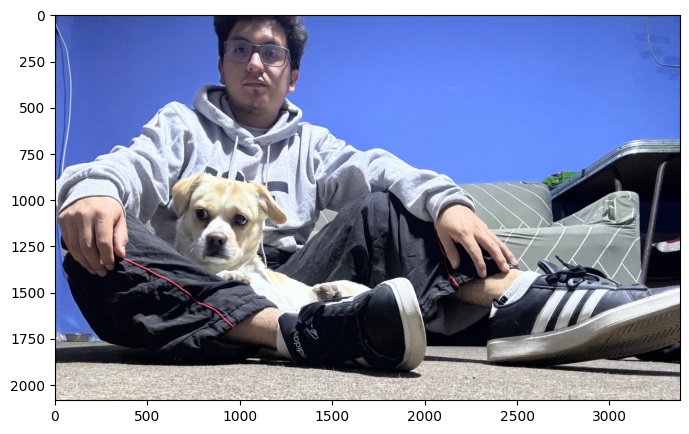

In [2]:
img     = cv2.imread("../../data/images/image_1.jpeg")
print(img.shape)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)


fig=plt.figure(figsize=(10,5))
plt.imshow(img_rgb)
plt.show()

# Load model

In [3]:
model = VITPoseModel(device='cuda', model_name='ViTPose+_huge_coco_wholebody',
                 use_thresholding=False,kpt_thr=0.5)

splitted_vitpose+_huge_coco_wholebody_half.pth: 1.27GB [00:19, 65.9MB/s]                               


In [4]:
keypoints, scores = model.predict(frame_rgb=img_rgb)

In [5]:
scores[0,:10]

array([0.96097565, 0.9550237 , 0.94122684, 0.92002624, 0.8841052 ,
       0.88628334, 0.90115124, 0.8766245 , 0.76899374, 0.8903385 ],
      dtype=float32)

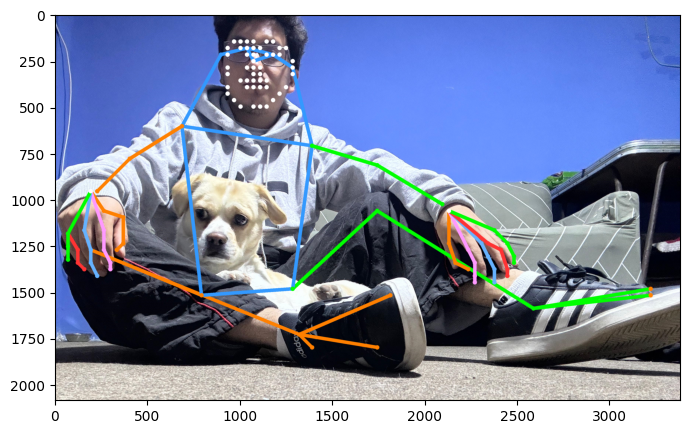

In [6]:
img_rgb_new2 = copy.deepcopy(img_rgb)
img_rgb_new2 = draw_skeleton(img_rgb_new2, keypoints, scores, kpt_thr=0.5,
                             line_width=18,radius=12)

fig=plt.figure(figsize=(10,5))
plt.imshow(img_rgb_new2)
plt.show()


In [7]:
keypoints.shape,scores.shape

((1, 133, 2), (1, 133))

In [8]:
type(keypoints),type(scores)

(numpy.ndarray, numpy.ndarray)

In [9]:
keypoints[0][:5],scores[0][:5]

(array([[1073.854  ,  249.3125 ],
        [1179.479  ,  214.10425],
        [1038.6458 ,  178.89575],
        [1285.104  ,  284.52075],
        [ 897.8125 ,  214.10425]], dtype=float32),
 array([0.96097565, 0.9550237 , 0.94122684, 0.92002624, 0.8841052 ],
       dtype=float32))